# UMAP de Banking77 sobre el subconjunto de 8 labels

Este notebook visualiza el subset generado a partir de Banking77 para estudiar si las 8 labels seleccionadas forman una masa semantica suficientemente coherente para clustering conjunto.

Objetivos:
- Cargar el subset exportado en el EDA.
- Explorar longitud y distribucion por labels.
- Proyectar el subset con UMAP usando BoW, TF-IDF, Nomic y Qwen3 embeddings.
- Visualizar la separacion entre labels y guardar artefactos reproducibles.

In [1]:
from __future__ import annotations

import importlib.util
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from umap import UMAP

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_colwidth", 120)

/home/gabriel/clase/TFG/TFG-Chatbot/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Resolver el root del repositorio y preparar rutas de salida
CANDIDATE_ROOT = Path.cwd().resolve()
if CANDIDATE_ROOT.name == "notebooks" and CANDIDATE_ROOT.parent.name == "validation":
    ROOT = CANDIDATE_ROOT.parent.parent
else:
    ROOT = next(
        (
            p
            for p in [CANDIDATE_ROOT, *CANDIDATE_ROOT.parents]
            if (
                p
                / "validation"
                / "results"
                / "banking77_eda"
                / "tables"
                / "banking77_similar8_subset.csv"
            ).exists()
        ),
        CANDIDATE_ROOT,
    )

EDA_TABLES = ROOT / "validation" / "results" / "banking77_eda" / "tables"
UMAP_DIR = ROOT / "validation" / "results" / "banking77_umap"
TABLES_DIR = UMAP_DIR / "tables"
FIGURES_DIR = UMAP_DIR / "figures"
CACHE_DIR = UMAP_DIR / "cache"
for p in [UMAP_DIR, TABLES_DIR, FIGURES_DIR, CACHE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Cargar helper local para embeddings en Ollama
ollama_module_path = ROOT / "validation" / "representation" / "ollama_embeddings.py"
ollama_spec = importlib.util.spec_from_file_location(
    "validation.representation.ollama_embeddings",
    ollama_module_path,
 )
if ollama_spec is None or ollama_spec.loader is None:
    raise ImportError(f"No se pudo cargar el modulo de embeddings: {ollama_module_path}")
ollama_module = importlib.util.module_from_spec(ollama_spec)
ollama_spec.loader.exec_module(ollama_module)
OllamaEmbeddings = ollama_module.OllamaEmbeddings

print(f"ROOT: {ROOT}")
print(f"Subset source: {EDA_TABLES / 'banking77_similar8_subset.csv'}")
print(f"Output dir: {UMAP_DIR}")
print(f"Cache dir: {CACHE_DIR}")

ROOT: /home/gabriel/clase/TFG/TFG-Chatbot
Subset source: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/banking77_eda/tables/banking77_similar8_subset.csv
Output dir: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/banking77_umap
Cache dir: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/banking77_umap/cache


In [3]:
# Cargar el subset de 8 labels
subset_path = EDA_TABLES / "banking77_similar8_subset.csv"
labels_path = EDA_TABLES / "banking77_similar8_selected_labels.csv"

df = pd.read_csv(subset_path)
selected_labels = pd.read_csv(labels_path)["label"].tolist()

df["text"] = df["text"].astype(str).str.strip()
df["label"] = df["label"].astype(str)
df = df[df["text"].str.len() > 0].drop_duplicates(subset=["text"]).reset_index(drop=True)
df["char_len"] = df["text"].str.len()
df["tok_len"] = df["text"].str.findall(r"\w+").str.len()

print(f"Filas del subset: {len(df)}")
print(f"Labels unicas: {df['label'].nunique()}")
print(f"Labels seleccionados: {selected_labels}")
display(df.head())

Filas del subset: 1176
Labels unicas: 8
Labels seleccionados: ['beneficiary_not_allowed', 'cash_withdrawal_charge', 'cash_withdrawal_not_recognised', 'card_arrival', 'card_delivery_estimate', 'card_not_working', 'card_linking', 'card_payment_not_recognised']


,text,label,char_len,tok_len
0,I am still waiting on my card?,card_arrival,30,7
1,What can I do if my card still hasn't arrived after 2 weeks?,card_arrival,60,14
2,I have been waiting over a week. Is the card still coming?,card_arrival,58,12
3,Can I track my card while it is in the process of delivery?,card_arrival,59,13
4,"How do I know if I will get my card, or if it is lost?",card_arrival,54,15


In [4]:
# Resumen descriptivo del subset
subset_summary = {
    "n_rows": len(df),
    "n_labels": int(df["label"].nunique()),
    "char_len_mean": float(df["char_len"].mean()),
    "char_len_median": float(df["char_len"].median()),
    "tok_len_mean": float(df["tok_len"].mean()),
    "tok_len_median": float(df["tok_len"].median()),
}
subset_summary_df = pd.DataFrame([subset_summary])
subset_summary_df.to_csv(TABLES_DIR / "banking77_subset_summary.csv", index=False, encoding="utf-8")
display(subset_summary_df)

label_counts = df["label"].value_counts().rename_axis("label").reset_index(name="count")
label_counts.to_csv(TABLES_DIR / "banking77_subset_label_counts.csv", index=False, encoding="utf-8")
display(label_counts)

,n_rows,n_labels,char_len_mean,char_len_median,tok_len_mean,tok_len_median
0,1176,8,61.39881,49.0,12.996599,11.0


,label,count
0,cash_withdrawal_charge,177
1,card_payment_not_recognised,168
2,cash_withdrawal_not_recognised,160
3,beneficiary_not_allowed,156
4,card_arrival,153
5,card_linking,139
6,card_delivery_estimate,112
7,card_not_working,111


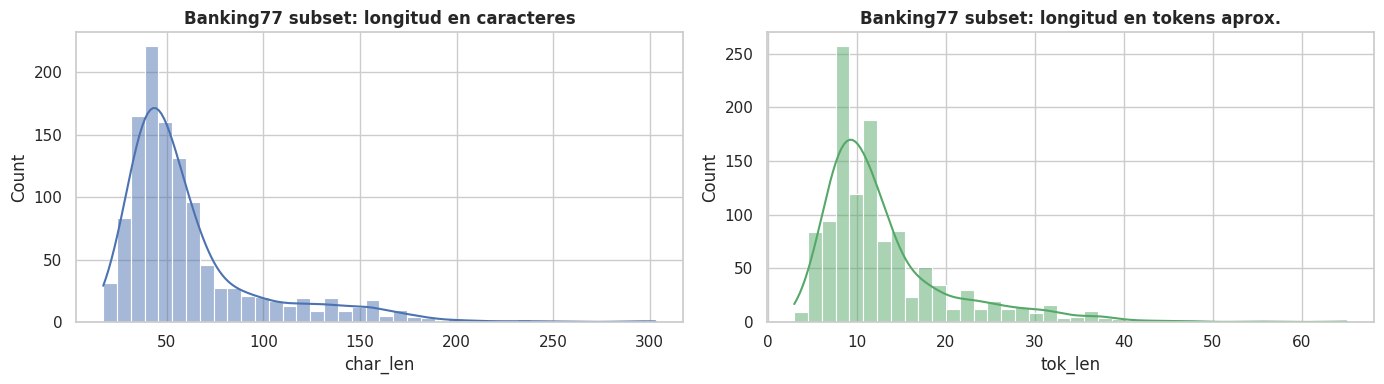

In [5]:
# Distribuciones basicas
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["char_len"], bins=40, kde=True, ax=axes[0], color="#4c72b0")
axes[0].set_title("Banking77 subset: longitud en caracteres")
axes[0].set_xlabel("char_len")

sns.histplot(df["tok_len"], bins=40, kde=True, ax=axes[1], color="#55a868")
axes[1].set_title("Banking77 subset: longitud en tokens aprox.")
axes[1].set_xlabel("tok_len")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "banking77_subset_length_distributions.png", dpi=180, bbox_inches="tight")
plt.show()

In [6]:
# Frecuencias lexicales
texts = df["text"].tolist()

cv_uni = CountVectorizer(stop_words="english", ngram_range=(1, 1), min_df=2, max_df=0.9)
X_uni = cv_uni.fit_transform(texts)
freq_uni = np.asarray(X_uni.sum(axis=0)).ravel()
top_uni_idx = np.argsort(freq_uni)[::-1][:25]
df_top_uni = pd.DataFrame({
    "term": np.array(cv_uni.get_feature_names_out())[top_uni_idx],
    "count": freq_uni[top_uni_idx],
})

cv_bi = CountVectorizer(stop_words="english", ngram_range=(2, 2), min_df=2, max_df=0.9)
X_bi = cv_bi.fit_transform(texts)
freq_bi = np.asarray(X_bi.sum(axis=0)).ravel()
top_bi_idx = np.argsort(freq_bi)[::-1][:25]
df_top_bi = pd.DataFrame({
    "term": np.array(cv_bi.get_feature_names_out())[top_bi_idx],
    "count": freq_bi[top_bi_idx],
})

df_top_uni.to_csv(TABLES_DIR / "banking77_subset_top_unigrams.csv", index=False, encoding="utf-8")
df_top_bi.to_csv(TABLES_DIR / "banking77_subset_top_bigrams.csv", index=False, encoding="utf-8")
display(df_top_uni.head(10))
display(df_top_bi.head(10))

,term,count
0,card,600
1,cash,182
2,app,166
3,withdrawal,139
4,account,124
5,payment,122
6,money,106
7,transfer,101
8,charged,100
9,fee,94


,term,count
0,new card,87
1,cash withdrawal,77
2,didn make,40
3,card app,33
4,don recognize,29
5,card sent,24
6,charged fee,24
7,track card,23
8,transfer account,21
9,extra fee,19


In [7]:
# Representaciones vectoriales
bow_vectorizer = CountVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2, max_df=0.95)
tfidf_vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)

X_bow = bow_vectorizer.fit_transform(texts)
X_tfidf = tfidf_vectorizer.fit_transform(texts)

ollama_host = os.getenv("OLLAMA_HOST", "localhost")
ollama_port = int(os.getenv("OLLAMA_PORT", "11434"))
nomic_embedder = OllamaEmbeddings(model="nomic-embed-text", host=ollama_host, port=ollama_port)
qwen_embedder = OllamaEmbeddings(model="qwen3-embedding:0.6b", host=ollama_host, port=ollama_port)

nomic_cache = CACHE_DIR / f"nomic_embeddings_n{len(texts)}.npy"
qwen_cache = CACHE_DIR / f"qwen3_embeddings_n{len(texts)}.npy"

def load_or_create_embeddings(cache_path: Path, embedder: OllamaEmbeddings, texts: list[str], name: str) -> np.ndarray:
    if cache_path.exists():
        return np.load(cache_path)

    try:
        X = embedder.embed_batch(texts).astype(np.float32)
        np.save(cache_path, X)
        return X
    except Exception as exc:
        raise RuntimeError(
            f"No se pudieron generar embeddings de {name}. Revisa Ollama en {ollama_host}:{ollama_port} y que el modelo '{embedder.model}' este disponible.",
        ) from exc

X_nomic = load_or_create_embeddings(nomic_cache, nomic_embedder, texts, "Nomic")
X_qwen = load_or_create_embeddings(qwen_cache, qwen_embedder, texts, "Qwen3")

def matrix_stats(name: str, X) -> dict:
    n, d = X.shape
    nnz = int(X.nnz) if hasattr(X, "nnz") else int(np.count_nonzero(X))
    return {
        "representation": name,
        "n_samples": int(n),
        "n_features": int(d),
        "nnz": nnz,
        "sparsity": float(1.0 - (nnz / (n * d))),
        "avg_nnz_per_doc": float(nnz / n),
    }

repr_stats = pd.DataFrame(
    [
        matrix_stats("bow", X_bow),
        matrix_stats("tfidf", X_tfidf),
        matrix_stats("nomic", X_nomic),
        matrix_stats("qwen3", X_qwen),
    ]
)
repr_stats.to_csv(TABLES_DIR / "banking77_subset_representation_stats.csv", index=False, encoding="utf-8")
display(repr_stats)

,representation,n_samples,n_features,nnz,sparsity,avg_nnz_per_doc
0,bow,1176,2022,21383,0.991008,18.182823
1,tfidf,1176,2022,21383,0.991008,18.182823
2,nomic,1176,768,903168,0.000000,768.000000
3,qwen3,1176,1024,1204224,0.000000,1024.000000


In [8]:
# UMAP sobre las cuatro representaciones
umap_kwargs = {
    "n_components": 2,
    "n_neighbors": 15,
    "min_dist": 0.12,
    "metric": "cosine",
    "random_state": 42,
}

def project_representation(name: str, matrix) -> pd.DataFrame:
    reducer = UMAP(**umap_kwargs)
    coords = reducer.fit_transform(matrix)
    out = df[["text", "label", "char_len", "tok_len"]].copy()
    out["representation"] = name
    out["umap_1"] = coords[:, 0]
    out["umap_2"] = coords[:, 1]
    out.to_csv(TABLES_DIR / f"banking77_subset_{name}_umap.csv", index=False, encoding="utf-8")
    return out

proj_bow = project_representation("bow", X_bow)
proj_tfidf = project_representation("tfidf", X_tfidf)
proj_nomic = project_representation("nomic", X_nomic)
proj_qwen = project_representation("qwen3", X_qwen)

display(proj_bow.head())

/home/gabriel/clase/TFG/TFG-Chatbot/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/gabriel/clase/TFG/TFG-Chatbot/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/gabriel/clase/TFG/TFG-Chatbot/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/gabriel/clase/TFG/TFG-Chatbot/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,text,label,char_len,tok_len,representation,umap_1,umap_2
0,I am still waiting on my card?,card_arrival,30,7,bow,10.165215,8.268360
1,What can I do if my card still hasn't arrived after 2 weeks?,card_arrival,60,14,bow,8.480000,7.504667
2,I have been waiting over a week. Is the card still coming?,card_arrival,58,12,bow,11.080812,11.193910
3,Can I track my card while it is in the process of delivery?,card_arrival,59,13,bow,10.442423,10.333222
4,"How do I know if I will get my card, or if it is lost?",card_arrival,54,15,bow,9.038395,10.356855


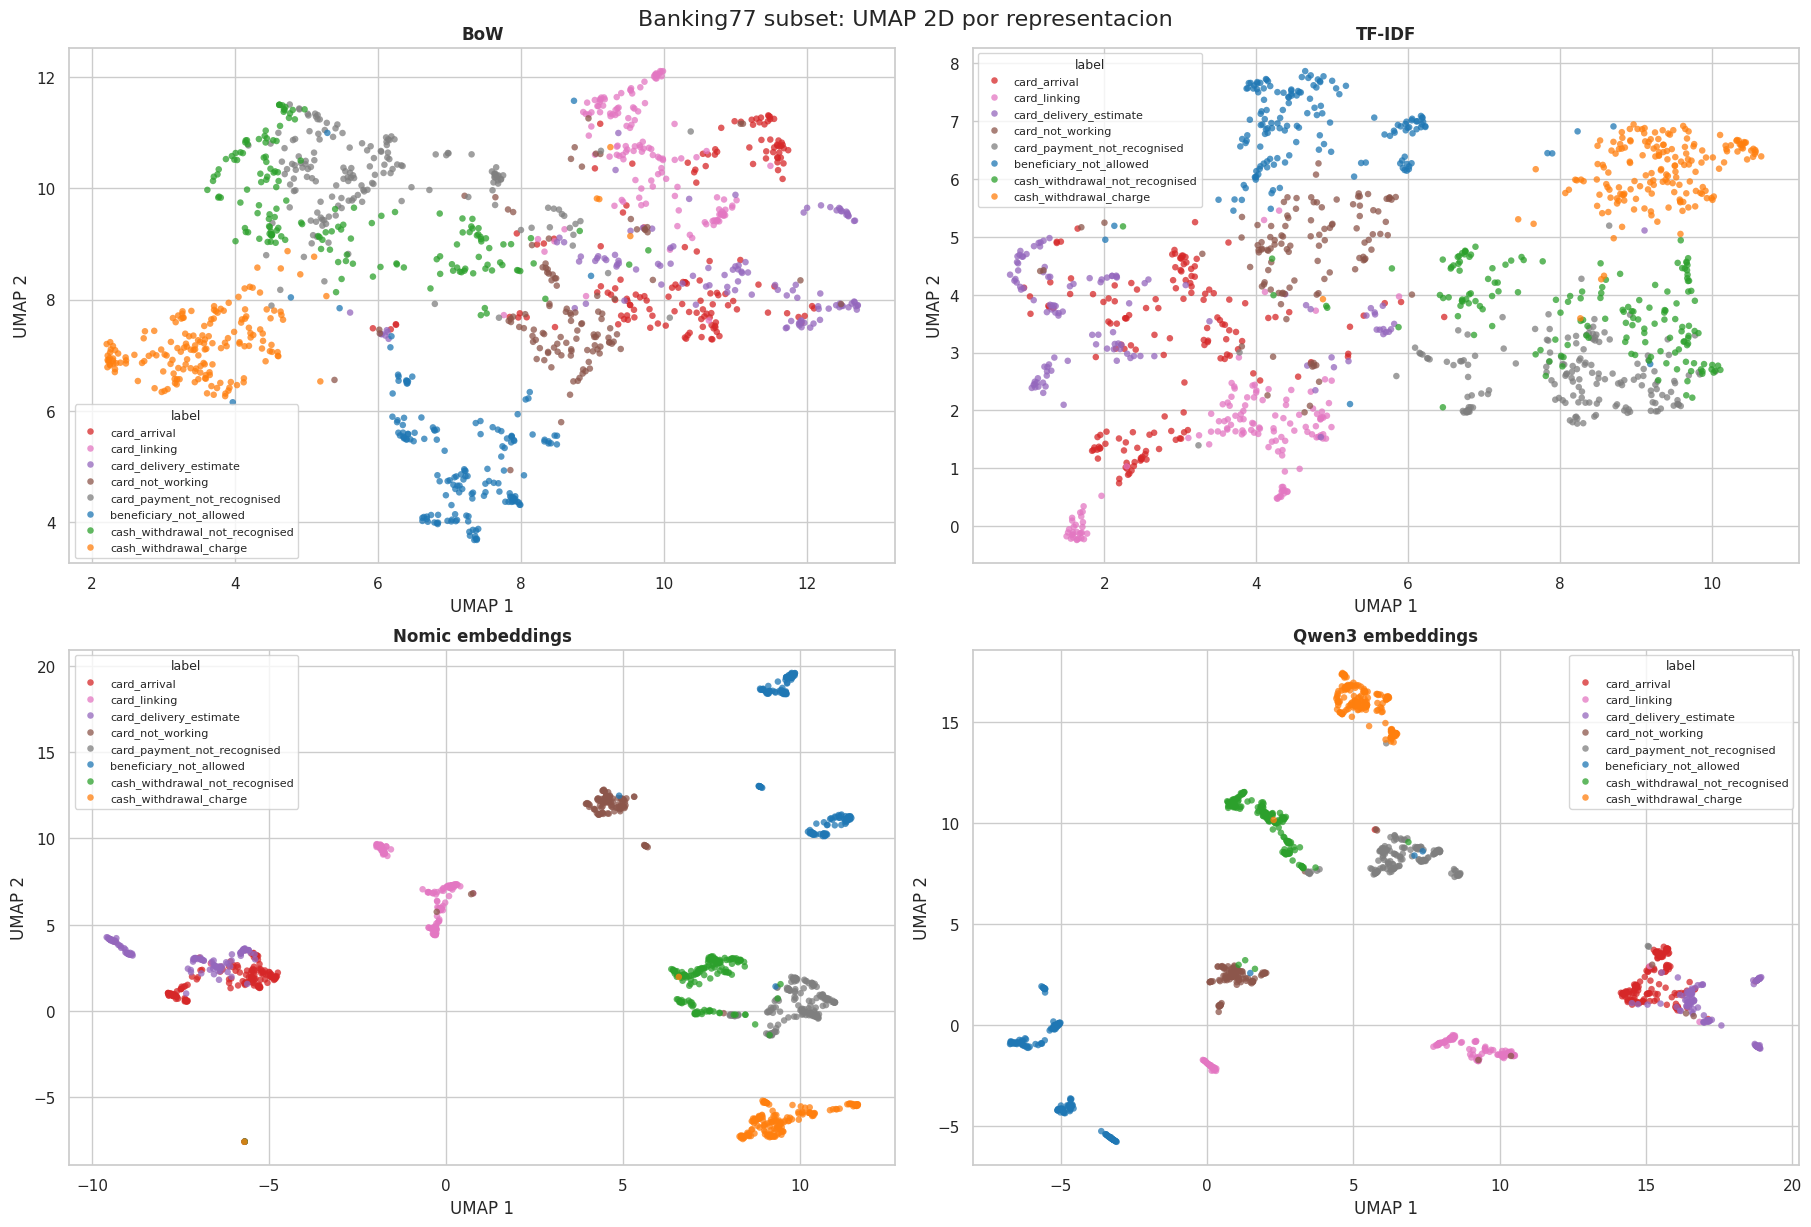

In [9]:
# Visualizacion comparativa de UMAP
palette = dict(zip(selected_labels, sns.color_palette("tab10", n_colors=len(selected_labels)).as_hex()))
plots = [
    (proj_bow, "BoW"),
    (proj_tfidf, "TF-IDF"),
    (proj_nomic, "Nomic embeddings"),
    (proj_qwen, "Qwen3 embeddings"),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)
for ax, (proj, title) in zip(axes.flat, plots):
    sns.scatterplot(
        data=proj,
        x="umap_1",
        y="umap_2",
        hue="label",
        palette=palette,
        s=22,
        alpha=0.75,
        linewidth=0,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.legend(title="label", fontsize=8, title_fontsize=9, loc="best")

fig.suptitle("Banking77 subset: UMAP 2D por representacion", fontsize=16, y=1.01)
fig.savefig(FIGURES_DIR / "banking77_subset_umap_four_representations.png", dpi=180, bbox_inches="tight")
plt.show()

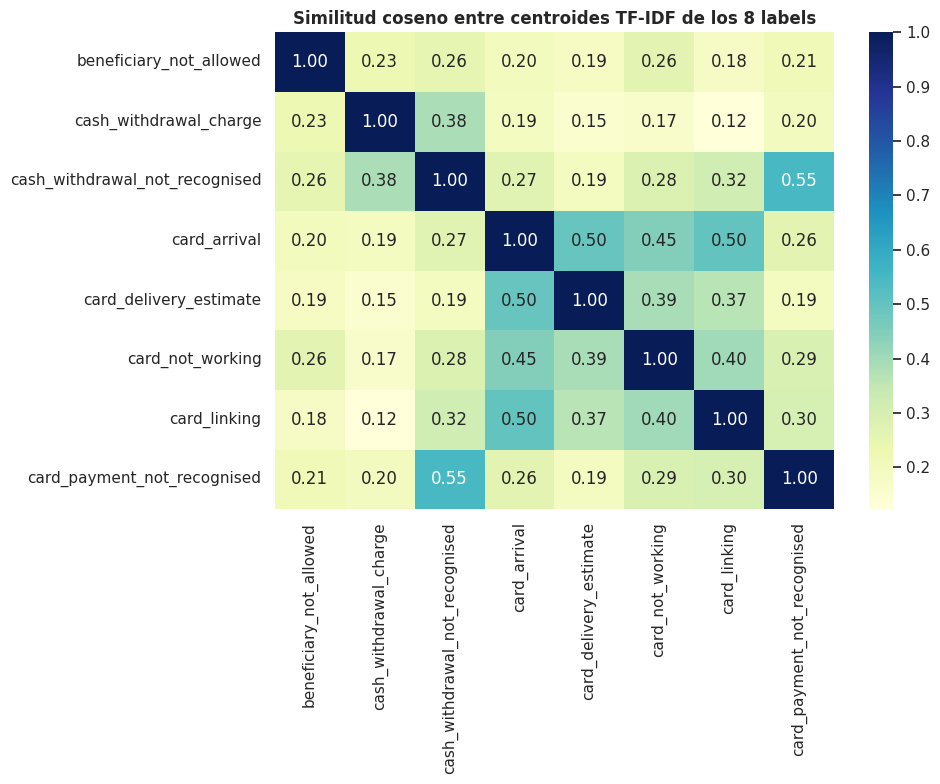

In [10]:
# Heatmap de centroides TF-IDF por label
from sklearn.metrics.pairwise import cosine_similarity

label_centroids = []
for label in selected_labels:
    rows = np.where(df["label"].values == label)[0]
    centroid = np.asarray(X_tfidf[rows].mean(axis=0)).ravel()
    label_centroids.append(centroid)

centroids = np.vstack(label_centroids)
similarity = cosine_similarity(centroids)
sim_df = pd.DataFrame(similarity, index=selected_labels, columns=selected_labels)
sim_df.to_csv(TABLES_DIR / "banking77_subset_centroid_cosine_similarity.csv", encoding="utf-8")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim_df, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax)
ax.set_title("Similitud coseno entre centroides TF-IDF de los 8 labels")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "banking77_subset_centroid_similarity.png", dpi=180, bbox_inches="tight")
plt.show()

## Resultado principal

Este notebook deja listo el subset de Banking77 para clustering y guarda las visualizaciones en validation/results/banking77_umap/.

Las figuras mas relevantes son:
- banking77_subset_umap_four_representations.png
- banking77_subset_centroid_similarity.png